# MIL aggregator comparison

Cancer-type classification (healthy / H&N / meningioma / chordoma-chondrosarcoma) with the
gated-attention aggregator swapped for a transformer (TransMIL) or a mixture of aggregators (MoA).
Only the aggregation module differs; same CNN cell-encoder and leave-one-plate-out protocol.

Trained here: gated attention with mini-batch training, TransMIL (single-bag and mini-batch), and MoA
with four gated-attention or four transformer experts (MoA-MIL, MoA-TransMIL). The single-bag gated
attention (MIL) baseline is the cancer-type MIL model from `cancer_type_mil.ipynb` (Fig. 3g) and is not
retrained here. Per-fold predictions are cached to `results/mil_aggregator_comparison/` and plotted as
Fig. S3f in `figure_notebooks/figures_3_S3.ipynb`. Set `RUN_TRAINING = True` to (re)train.

In [1]:
import os, sys, glob
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt

from data import PlateDataset
from util import torch_random_choice
from models import GatedAttentionMulti, TransMIL, MoA
from training import train_model, train_batched, train_moa

In [2]:
device = 'cuda:0'  # change to an available GPU

USE_PLATES = np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
USE_GROUPS = ['healthy', 'H&N cancer', 'CNS-Meningioma', 'Chordoma/Chondrosarcoma']
GROUP_MAP = {'healthy': 0, 'H&N cancer': 1, 'CNS-Meningioma': 2, 'Chordoma/Chondrosarcoma': 3, 'CNS-Glioma': 4}

MODELS_DIR = '/ewsc/hschluet/models/pbmc5/revision_rerun'
RESULTS_DIR = 'results/mil_aggregator_comparison'
os.makedirs(RESULTS_DIR, exist_ok=True)
AUGMENT = T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2),
                     T.RandomHorizontalFlip(), T.RandomVerticalFlip()])

# mini-batch: 31250 steps x 16 bags = 500k bag-exposures; single-bag: 500k iterations (1 bag/step)
NUM_STEPS, BATCH, LR, NUM_SINGLE = 31250, 16, 1e-4, 500_000

# Single-bag gated attention reuses the cancer-type MIL models (prefix 'aggcmp'); the
# rest are trained here (prefix 'faithful'). All are cache-guarded, so existing folds are skipped.
METHODS = {
    'gatedattn':    dict(seeds=[101, 202, 303, 404, 505], kind='single',  prefix='aggcmp',   build=lambda: GatedAttentionMulti(classes=4, branches=5)),
    'abmil_mb':     dict(seeds=[101, 202, 303, 404, 505], kind='batched', prefix='faithful', build=lambda: GatedAttentionMulti(classes=4, branches=5)),
    'transmil_sb':  dict(seeds=[101, 202, 303, 404, 505], kind='single',  prefix='faithful', build=lambda: TransMIL(classes=4)),
    'transmil':     dict(seeds=[101, 202, 303, 404, 505], kind='batched', prefix='faithful', build=lambda: TransMIL(classes=4)),
    'moa_abmil':    dict(seeds=[101, 202, 303],           kind='moa',     prefix='faithful', build=lambda: MoA(classes=4, base='abmil')),
    'moa_transmil': dict(seeds=[101, 202, 303],           kind='moa',     prefix='faithful', build=lambda: MoA(classes=4, base='transmil')),
}
LABELS = {'gatedattn': 'MIL (single-bag)', 'abmil_mb': 'MIL (mini-batch)',
          'transmil_sb': 'TransMIL (single-bag)', 'transmil': 'TransMIL (mini-batch)',
          'moa_abmil': 'MoA-MIL', 'moa_transmil': 'MoA-TransMIL'}

## Training  (leave-one-plate-out)

For each held-out plate, that plate's patients are dropped from the training bags and the model is
trained on the other nine. Cache-guarded: skips any `(method, seed, plate)` already on disk. The full
sweep (six methods x seeds x plates) is heavy; set `RUN_TRAINING = True` to train any missing folds.

In [3]:
RUN_TRAINING = False


def eval_predictions(model, test_loader):
    model.eval()
    np.random.seed(1232412); torch.manual_seed(124514); torch.cuda.manual_seed_all(13513)
    rows = []
    for bag, lab, pat, group in test_loader:
        with torch.no_grad():
            out = model(bag.to(device))
        rows.append({'pat': pat, 'group': group, 'lab': int(lab.item()), 'pred': int(out[1].item())})
    return pd.DataFrame(rows)


if RUN_TRAINING:
    data = PlateDataset(list(USE_PLATES)); info = data.info
    cdf = info[info['group'].isin(USE_GROUPS)].groupby(['patient', 'time'])['cell'].count().reset_index()
    cdf = cdf[cdf['cell'] > 100]
    p01s = cdf[(cdf['time'] == 1) | (cdf['time'] == 0)]['patient'].unique()
    pat_on_plate = info.groupby('plate')['patient'].unique()

    def group_bagloader(use_patients, use_plates, bag_size=50, transform=T.CenterCrop(28)):
        use_idx = torch.argwhere(torch.from_numpy(
            (info['plate'].isin(use_plates) & info['time'].isin([0, 1])).values)).flatten()
        use_data = transform(data.imgs[use_idx].to(device))
        plate_pats = np.concatenate(info.groupby(['plate'])['patient'].unique().loc[use_plates].values)
        up = use_patients[np.isin(use_patients, plate_pats)]
        pat_groups = info.groupby(['group'])['patient'].unique().map(lambda x: x[np.isin(x, up)])
        lut = {pat: torch.argwhere(torch.from_numpy((info.loc[use_idx]['patient'] == pat).values)).flatten().to(device) for pat in up}
        while True:
            label = np.random.choice(USE_GROUPS)
            pat = np.random.choice(pat_groups[label])
            xs = use_data[torch_random_choice(lut[pat], size=bag_size)]
            yield xs.float(), torch.tensor(GROUP_MAP[label]).to(device)

    def test_group_bagloader(use_plates, bag_size=50, reps=5, transform=T.CenterCrop(28)):
        use_idx = torch.argwhere(torch.from_numpy(
            (info['plate'].isin(use_plates) & info['time'].isin([0, 1])).values)).flatten()
        use_data = transform(data.imgs[use_idx].to(device))
        pat_groups = info.groupby(['patient'])['group'].max()
        pat_plates = info.groupby(['patient'])['plate'].unique()
        for pat in p01s:
            if not np.isin(pat_plates[pat], use_plates).any():
                continue
            pat_idx = torch.argwhere(torch.from_numpy((info.loc[use_idx]['patient'] == pat).values)).flatten().to(device)
            for _ in range(reps):
                xs = use_data[torch_random_choice(pat_idx, size=bag_size)]
                yield xs.float(), torch.tensor(GROUP_MAP[pat_groups[pat]]).to(device), pat, pat_groups[pat]

    for method, cfg in METHODS.items():
        for seed in cfg['seeds']:
            for plate in USE_PLATES:
                fname = f"{cfg['prefix']}_{method}_s{seed}_without_plate_{plate}"
                model_path = f'{MODELS_DIR}/{fname}_model.pt'
                pred_path = f'{RESULTS_DIR}/preds_{method}_s{seed}_plate_{plate}.csv'
                if os.path.exists(model_path) and os.path.exists(pred_path):
                    continue
                print('training', fname, flush=True)
                np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
                model = cfg['build']()
                train_loader = group_bagloader(use_patients=p01s[~np.isin(p01s, pat_on_plate.loc[plate])],
                                                use_plates=USE_PLATES[USE_PLATES != plate].copy())
                if cfg['kind'] == 'batched':
                    hist = train_batched(model, train_loader, NUM_STEPS, BATCH, LR, AUGMENT, device, seed)
                    torch.save(model.state_dict(), model_path)
                    pd.DataFrame(hist).to_csv(f'{MODELS_DIR}/{fname}_losses.csv', index=False)
                elif cfg['kind'] == 'moa':
                    hist = train_moa(model, train_loader, NUM_STEPS, BATCH, LR, transform=AUGMENT, device=device, seed=seed)
                    torch.save(model.state_dict(), model_path)
                    pd.DataFrame(hist).to_csv(f'{MODELS_DIR}/{fname}_losses.csv', index=False)
                elif cfg['kind'] == 'single':
                    train_model(model, bag_loader=train_loader, num_iter=NUM_SINGLE, lr=LR, transform=AUGMENT,
                                outdir=MODELS_DIR, device=device, fname=fname, plot=False, save_model=True, seed=seed, bar=False)
                df = eval_predictions(model, test_group_bagloader(use_plates=[plate]))
                df['plate'] = plate; df['method'] = method
                df.to_csv(pred_path, index=False)
    print('training sweep complete')
else:
    print('RUN_TRAINING=False — predictions are cached; the comparison figure is Fig. S3f in figures_3_S3.')

RUN_TRAINING=False — predictions are cached; the comparison figure is Fig. S3f in figures_3_S3.


## Loss curves
Smoothed training loss per method (seed 101); one line per leave-one-plate-out fold.

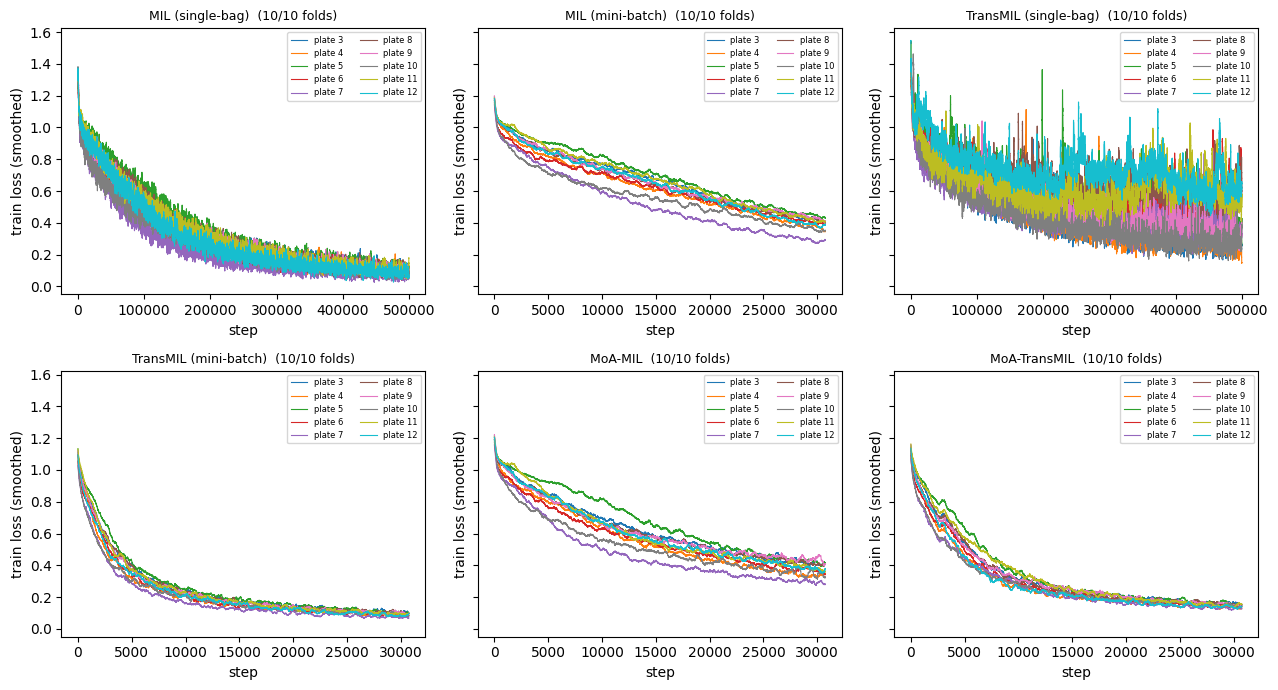

In [4]:
def load_losses(method, seed=101):
    prefix = METHODS[method]['prefix']
    out = {}
    for p in range(3, 13):
        fp = f'{MODELS_DIR}/{prefix}_{method}_s{seed}_without_plate_{p}_losses.csv'
        if os.path.exists(fp):
            d = pd.read_csv(fp)
            out[p] = (d['loss'] if 'loss' in d.columns else d['train loss']).values
    return out


def smooth(x, w=500):
    w = min(w, max(1, len(x) // 5))
    return np.convolve(x, np.ones(w) / w, 'valid')


fig, axs = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, method in zip(axs.flat, list(METHODS)):
    L = load_losses(method)
    for p, y in sorted(L.items()):
        ax.plot(smooth(y), lw=0.8, label=f'plate {p}')
    ax.set_title(f'{LABELS[method]}  ({len(L)}/10 folds)', fontsize=9)
    ax.set_xlabel('step'); ax.set_ylabel('train loss (smoothed)')
    if L:
        ax.legend(fontsize=6, ncol=2)
fig.tight_layout()